# GPU PBKDF2-HMAC-SHA1 benchmark (Kaggle T4x2 / P100)

**Project 20 -- Wi-Fi Password Cracking Attack (CSE 406).** This notebook fills the gap the
report currently has: `defend/estimate.py` only prints a *theoretical* keyspace/time table and
a graph derived from an assumed candidate rate, with no experiment measuring the assumed rate,
and no GPU numbers at all. This notebook:

1. Implements our own batched PBKDF2-HMAC-SHA1 (the PMK derivation, `hashlib.pbkdf2_hmac`'s
   exact algorithm, RFC 2898 / IEEE 802.11i) as a from-scratch PyTorch GPU kernel -- **own code**,
   not aircrack-ng/Hashcat, exactly the same rule the graded CLI tool follows.
2. **Validates it byte-for-byte against `hashlib.pbkdf2_hmac`** before trusting any timing.
3. Measures real throughput (candidates/sec) on CPU (1 core, all cores) and GPU (single GPU,
   and both GPUs if a T4x2 instance is selected), across a range of batch sizes.
4. Plugs the *measured* rates into the project's own `defend/estimate.py` formula and compares
   the resulting *predicted* crack time against an *actually executed* crack timing -- the literal
   "estimate vs experiment" comparison the report is missing.
5. Saves a results table (CSV) and a chart (PNG) to paste directly into the report.

**Kaggle setup:** Notebook Settings (right sidebar) -> Accelerator -> **GPU T4 x2** or **GPU P100**.
Internet must be ON if you want to `pip install` anything extra (not required here -- only
`torch`, which every Kaggle GPU image ships with, plus stdlib).


## GPU-batched PBKDF2-HMAC-SHA1 kernel (own code)

This is **our own** from-scratch SHA-1 / HMAC-SHA1 / PBKDF2-HMAC-SHA1 implementation, written as
batched PyTorch tensor operations so one kernel launch processes thousands of candidate
passphrases at once on the GPU. It is **not** aircrack-ng, Hashcat, or any other cracking tool --
it is the exact same algorithm `wpacrack/crypto/__init__.py` already implements with
`hashlib.pbkdf2_hmac`, just re-expressed as parallel tensor arithmetic instead of a Python loop.

Every 32-bit SHA-1 word is represented as an `int64` tensor with a `& 0xFFFFFFFF` mask applied
after every arithmetic op, so the modular (mod 2^32) arithmetic SHA-1 requires is exact regardless
of the underlying dtype.

**Speed note:** one PBKDF2 call makes ~8,190 separate calls to the one-block SHA-1 step below
(4096 iterations x 2 HMAC calls), each of which used to be dozens of individually-dispatched
small operations -- the actual source of the "fixed few-minutes-per-call" cost measured earlier.
To fix that, the SHA-1 step is wrapped in `torch.compile(...)`: instead of Python asking the GPU
to do one tiny thing at a time (thousands of times per call), it records the *whole* one-block
recipe once, fuses it into a much smaller number of actual GPU launches, and replays that fused
version on every one of the ~8,190 repeated calls. There's a **two-step safety net** (plain
`torch.compile` first, falling back automatically to the original, unoptimized version if that
fails) since this can't be tested without a live GPU. (An earlier version also tried
`mode="reduce-overhead"`, which measured very well single-threaded but turned out to crash when
replayed concurrently across two GPUs -- see the kernel cell's own comments for what happened and
why it was removed.) Whichever tier ends up active is printed after the validation cell runs.

**Before any benchmark number in this notebook is trusted, the very next cell validates this
kernel byte-for-byte against Python's own `hashlib.pbkdf2_hmac`** for many random passwords and
SSID lengths (including the canonical IEEE 802.11i test vector) -- this check exercises whichever
tier is actually active, so a compiled-but-subtly-wrong kernel would still be caught here. **If
that validation cell fails, STOP -- do not trust any timing below it**, and see the fallback note
in the cell below for how to force plain eager mode if `torch.compile` is the culprit.


In [1]:
import struct
import torch

MASK32 = 0xFFFFFFFF


def _rotl(x, n):
    return ((x << n) | (x >> (32 - n))) & MASK32


def _sha1_batch_eager(word_blocks: torch.Tensor) -> torch.Tensor:
    """word_blocks: (B, n_blocks*16) int64 tensor of big-endian 32-bit message words,
    already padded per FIPS 180-4. Returns (B, 5) int64 tensor of digest words h0..h4.
    This is the original, uncompiled reference -- kept as the last-resort fallback below."""
    B = word_blocks.shape[0]
    n_blocks = word_blocks.shape[1] // 16
    device = word_blocks.device
    h0 = torch.full((B,), 0x67452301, dtype=torch.int64, device=device)
    h1 = torch.full((B,), 0xEFCDAB89, dtype=torch.int64, device=device)
    h2 = torch.full((B,), 0x98BADCFE, dtype=torch.int64, device=device)
    h3 = torch.full((B,), 0x10325476, dtype=torch.int64, device=device)
    h4 = torch.full((B,), 0xC3D2E1F0, dtype=torch.int64, device=device)

    for blk in range(n_blocks):
        w = [word_blocks[:, blk * 16 + i] for i in range(16)] + [None] * 64
        for i in range(16, 80):
            w[i] = _rotl(w[i - 3] ^ w[i - 8] ^ w[i - 14] ^ w[i - 16], 1)
        a, b, c, d, e = h0, h1, h2, h3, h4
        for i in range(80):
            if i < 20:
                f = (b & c) | ((~b & MASK32) & d)
                k = 0x5A827999
            elif i < 40:
                f = b ^ c ^ d
                k = 0x6ED9EBA1
            elif i < 60:
                f = (b & c) | (b & d) | (c & d)
                k = 0x8F1BBCDC
            else:
                f = b ^ c ^ d
                k = 0xCA62C1D6
            temp = (_rotl(a, 5) + f + e + k + w[i]) & MASK32
            e, d, c, b, a = d, c, _rotl(b, 30), a, temp
        h0 = (h0 + a) & MASK32
        h1 = (h1 + b) & MASK32
        h2 = (h2 + c) & MASK32
        h3 = (h3 + d) & MASK32
        h4 = (h4 + e) & MASK32
    return torch.stack([h0, h1, h2, h3, h4], dim=1)


# --- Tiered compile-with-fallback: try the fastest safe option first, fall back automatically
# (and permanently, for the rest of the session) if a tier errors out. This can't be pre-tested
# without a live GPU, so the safety net matters more than the choice of "best" tier.
#
# NOTE ON mode="reduce-overhead" (CUDA graphs): an earlier version of this kernel tried that
# mode first. On a live Kaggle T4x2 it worked perfectly for single-threaded, single-GPU use
# (Step 3 measured 1,200-2,200+ candidates/sec with it), but calling it CONCURRENTLY from two
# threads on two different GPUs -- which the dual-GPU cells below do on purpose -- crashed with
# an internal AssertionError, and *not* just on first use: it failed even after both devices had
# already been warmed up. That means the problem isn't a one-time compile race (which warmup
# fixes) but CUDA graph replay itself not tolerating this concurrent multi-GPU pattern. Rather
# than keep chasing that, "reduce-overhead" has been dropped entirely -- plain `torch.compile`
# (Inductor fusion, no CUDA graphs) still gives a very large speedup over eager and does not
# have this failure mode.
#
# THREAD SAFETY (still relevant for plain torch.compile): its first-ever compilation of a given
# (function, device, shape) is not safe to trigger from two threads at once -- confirmed
# separately on the same run. Two things handle this: (1) only the tiny bookkeeping below is
# lock-protected, never the (possibly slow) GPU call itself, so two threads on two different
# devices still run genuinely concurrently once compiled; (2) `warmup_sha1_backend(devices)`,
# called once sequentially (never from a thread) right after validation, exercises EVERY tier on
# EVERY device up front -- not just whichever tier happens to be active at the time -- so that
# even a later mid-session fallback never has to compile for the first time inside a thread pool.
import threading

_SHA1_TIER_NAMES = ["compile:default", "eager (unoptimized fallback)"]
_SHA1_TIER_FNS = [torch.compile(_sha1_batch_eager), _sha1_batch_eager]  # built once, reused everywhere
_active_tier = [0]
_tier_lock = threading.Lock()


def _sha1_batch(word_blocks: torch.Tensor) -> torch.Tensor:
    while True:
        with _tier_lock:
            idx = _active_tier[0]
            if idx >= len(_SHA1_TIER_FNS):
                raise RuntimeError("All tiers, including the plain eager fallback, failed -- this should not happen.")
            fn = _SHA1_TIER_FNS[idx]
        try:
            return fn(word_blocks)  # the actual (possibly slow) GPU call happens OUTSIDE the lock
        except Exception as e:
            with _tier_lock:
                if _active_tier[0] == idx:  # only the thread that first hit this failure escalates
                    print(f"[{_SHA1_TIER_NAMES[idx]}] failed ({type(e).__name__}: {e}) -- falling back to the next tier.")
                    _active_tier[0] += 1
            # otherwise another thread already escalated us past this tier -- just retry the loop


def active_sha1_backend() -> str:
    return _SHA1_TIER_NAMES[_active_tier[0]]


def force_eager_sha1():
    """Manual override: call this if you want to rule out torch.compile as the cause of a
    problem, or to get a clean eager-mode baseline for comparison."""
    with _tier_lock:
        _active_tier[0] = len(_SHA1_TIER_FNS) - 1
    print(f"Forced SHA1 backend to: {active_sha1_backend()}")


def warmup_sha1_backend(devices):
    """Sequentially (never concurrently) exercises EVERY tier on EVERY device, using TWO
    different tiny batch sizes each. Two different sizes matter: PyTorch's automatic
    dynamic-shape detection only marks the batch dimension as dynamic (so ANY later batch size
    reuses the same compiled graph with no further compilation) after it has seen a shape
    change. Calls each tier's function directly with a dummy word-block tensor -- the exact
    (B, 32) shape every real call uses -- rather than through _sha1_batch, so warmup exercises
    every tier regardless of which one is currently active."""
    for tier_idx, fn in enumerate(_SHA1_TIER_FNS):
        for d in devices:
            for n in (3, 7):
                try:
                    fn(torch.zeros((n, 32), dtype=torch.int64, device=d))
                except Exception as e:
                    print(f"[warmup] {_SHA1_TIER_NAMES[tier_idx]} on {d} failed ({type(e).__name__}: {e}) -- "
                          f"fine for now, it will simply be skipped if ever selected.")
    print(f"Warmup complete for devices {[str(d) for d in devices]}. Active backend: {active_sha1_backend()}")


def _bytes_to_padded_words(msg: bytes):
    """Standard FIPS 180-4 SHA-1 padding; returns the full padded message as a list of
    big-endian 32-bit words (length always a multiple of 16)."""
    ml = len(msg) * 8
    m = msg + b"\x80"
    while len(m) % 64 != 56:
        m += b"\x00"
    m += struct.pack(">Q", ml)
    return list(struct.unpack(">%dI" % (len(m) // 4), m))


def _words16_from_bytes64(b64: bytes):
    return list(struct.unpack(">16I", b64))


def pbkdf2_hmac_sha1_gpu(passwords, ssid: bytes, iterations: int, dklen: int, device):
    """Batched PBKDF2-HMAC-SHA1 (RFC 2898 / IEEE 802.11i PMK derivation), passwords is a
    list[bytes], each 1..64 bytes (true for every valid WPA2-PSK passphrase, 8..63 ASCII chars).
    Returns a (B, dklen) uint8 numpy array, one row per password, in the same order."""
    B = len(passwords)
    for p in passwords:
        if len(p) > 64:
            raise ValueError("key>64B pre-hash path not implemented in this kernel (not needed for WPA2-PSK)")

    ipad_rows = torch.empty((B, 16), dtype=torch.int64, device=device)
    opad_rows = torch.empty((B, 16), dtype=torch.int64, device=device)
    for row, pw in enumerate(passwords):
        key64 = pw + b"\x00" * (64 - len(pw))
        ikp = bytes(x ^ 0x36 for x in key64)
        okp = bytes(x ^ 0x5C for x in key64)
        ipad_rows[row] = torch.tensor(_words16_from_bytes64(ikp), dtype=torch.int64)
        opad_rows[row] = torch.tensor(_words16_from_bytes64(okp), dtype=torch.int64)

    hlen = 20
    n_out_blocks = -(-dklen // hlen)
    dk = torch.zeros((B, n_out_blocks * hlen), dtype=torch.int64, device=device)

    # Constant tail for keypad(64B)+digest(20B)=84B messages (every inner/outer call from
    # round 2 onward, and every outer call). Depends only on the fixed length 84.
    dummy84 = _bytes_to_padded_words(b"\x00" * 84)
    tail84 = torch.tensor(dummy84[21:], dtype=torch.int64, device=device)  # words after the 21 real words

    for out_block in range(1, n_out_blocks + 1):
        salt_ctr = ssid + struct.pack(">I", out_block)
        dummy_r1 = _bytes_to_padded_words(b"\x00" * 64 + salt_ctr)
        tail_r1 = torch.tensor(dummy_r1[16:], dtype=torch.int64, device=device)

        inner1_msg = torch.cat([ipad_rows, tail_r1.unsqueeze(0).expand(B, -1)], dim=1)
        inner1 = _sha1_batch(inner1_msg)
        outer1_msg = torch.cat([opad_rows, inner1, tail84.unsqueeze(0).expand(B, -1)], dim=1)
        u = _sha1_batch(outer1_msg)
        u_xor = u.clone()

        for _ in range(iterations - 1):
            inner_msg = torch.cat([ipad_rows, u, tail84.unsqueeze(0).expand(B, -1)], dim=1)
            inner = _sha1_batch(inner_msg)
            outer_msg = torch.cat([opad_rows, inner, tail84.unsqueeze(0).expand(B, -1)], dim=1)
            u = _sha1_batch(outer_msg)
            u_xor = u_xor ^ u

        off = (out_block - 1) * hlen
        # pack 5 x 32-bit words -> 20 bytes, big-endian, per row
        for wi in range(5):
            word = u_xor[:, wi]
            for byte_i in range(4):
                shift = (3 - byte_i) * 8
                dk[:, off + wi * 4 + byte_i] = (word >> shift) & 0xFF

    dk = dk[:, :dklen]
    return dk.to(torch.uint8).cpu().numpy()


## Step 1 -- Validate the kernel (must pass before trusting anything below)

In [2]:
import hashlib
import random

assert torch.cuda.is_available(), "No CUDA GPU visible -- on Kaggle, set Settings > Accelerator to GPU T4x2 or P100"
device = torch.device("cuda:0")
print("GPU(s) visible:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(" ", i, torch.cuda.get_device_name(i))

random.seed(20260918)

# 1. Canonical IEEE 802.11i / WPA test vector: PBKDF2-HMAC-SHA1("password","IEEE",4096,32)
#    == f42c6fc52df0ebef9ebb4b90b38a5f902e83fe1b135a70e23aed762e9710a12e
got = pbkdf2_hmac_sha1_gpu([b"password"], b"IEEE", 4096, 32, device)
want = hashlib.pbkdf2_hmac("sha1", b"password", b"IEEE", 4096, dklen=32)
assert bytes(got[0]) == want, (bytes(got[0]).hex(), want.hex())
print("Canonical IEEE vector OK:", bytes(got[0]).hex())

# 2. A real project fact: WPA2-PSK "Coherer"/"Induction" (Wireshark wpa-Induction.pcap PMK)
got2 = pbkdf2_hmac_sha1_gpu([b"Induction"], b"Coherer", 4096, 32, device)
want2 = hashlib.pbkdf2_hmac("sha1", b"Induction", b"Coherer", 4096, dklen=32)
assert bytes(got2[0]) == want2
print("Induction/Coherer PMK OK:", bytes(got2[0]).hex())

# 3. Batch of random passwords, varying length (8..63) and varying SSID length (0 and 32 bytes --
#    the two extremes that change the round-1 padding word count, the actual bug-prone part of a
#    batched kernel), full 4096 iterations, dklen=32. NOTE: this kernel's wall-clock cost per call
#    is dominated by a fixed ~27 million small tensor-op dispatches (independent of batch size --
#    see the notebook intro), so each call below costs roughly the same few minutes regardless of
#    how large a batch we validate; we therefore validate with a SMALL batch (24) at just the two
#    edge-case SSID lengths, which already exercises the risky code path without wasting GPU time
#    re-proving something a bigger batch would only repeat.
all_ok = True
for ssid_len in (0, 32):
    ssid = bytes(random.randint(32, 126) for _ in range(ssid_len))
    pws = ["".join(random.choice("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789")
                    for _ in range(random.randint(8, 63))).encode() for _ in range(24)]
    got_batch = pbkdf2_hmac_sha1_gpu(pws, ssid, 4096, 32, device)
    for pw, g in zip(pws, got_batch):
        w = hashlib.pbkdf2_hmac("sha1", pw, ssid, 4096, dklen=32)
        ok = bytes(g) == w
        all_ok &= ok
        if not ok:
            print("MISMATCH ssid_len=%d pw=%r" % (ssid_len, pw))
    print(f"ssid_len={ssid_len}: batch of {len(pws)} random passwords, 4096 iters -- all match hashlib")

assert all_ok, "GPU kernel does NOT match hashlib -- DO NOT trust any benchmark below. Stop and report this."
print("\nALL VALIDATION CHECKS PASSED -- the kernel is byte-identical to hashlib.pbkdf2_hmac.")
print(f"Active SHA1 backend: {active_sha1_backend()}")
print("It is now safe to use the measurements below in the report.")
print("(If you want a clean eager-mode baseline to compare against, call force_eager_sha1() and re-run this cell.)")


GPU(s) visible: 2
  0 Tesla T4
  1 Tesla T4
Canonical IEEE vector OK: f42c6fc52df0ebef9ebb4b90b38a5f902e83fe1b135a70e23aed762e9710a12e
Induction/Coherer PMK OK: a288fcf0caaacda9a9f58633ff35e8992a01d9c10ba5e02efdf8cb5d730ce7bc
ssid_len=0: batch of 24 random passwords, 4096 iters -- all match hashlib
ssid_len=32: batch of 24 random passwords, 4096 iters -- all match hashlib

ALL VALIDATION CHECKS PASSED -- the kernel is byte-identical to hashlib.pbkdf2_hmac.
Active SHA1 backend: compile:default
It is now safe to use the measurements below in the report.
(If you want a clean eager-mode baseline to compare against, call force_eager_sha1() and re-run this cell.)


## A real performance characteristic of this kernel (read before running the rest)

Without any fusion, this kernel dispatches **one PyTorch op per SHA-1 step**. A full PBKDF2 call
(4096 iterations x 2 SHA-1 calls x 80 rounds) issues on the order of **~27 million individual
tensor-op dispatches** -- and that count does **not** depend on batch size, since each op
processes a whole `(B,)` tensor in one dispatch. That was measured for real on a Kaggle T4x2: every
call cost ~577 seconds regardless of whether the batch had 1 or 64 candidates in it, because the
cost was dominated by Python/CUDA dispatch overhead, not raw GPU compute.

The kernel above now tries to fix exactly that, via `torch.compile` (see the kernel cell's own
comments): instead of one dispatch per tiny step, it records the whole SHA-1 step's recipe **once**
and replays a fused version on every one of the ~8,190 repeated calls inside a single PBKDF2 run.
Two practical consequences:

1. **The first call at any new batch size now costs extra** (a one-time compile), and *subsequent*
   calls at that same size should be much cheaper -- this is a real change from before, where every
   call cost the same regardless of order. Expect the very first cell that calls
   `pbkdf2_hmac_sha1_gpu` to feel slower than you might hope; that's the one-time compile, not a
   sign anything is broken.
2. **Bigger batches are still nearly free relative to smaller ones** -- so we still never chunk a
   wordlist into many small batches; each device processes its whole share in **one** call
   (falling back to a half-sized retry only if that runs out of GPU memory).

This can't be tested without a live GPU, so there's a built-in safety net: if `torch.compile`
fails at its first real use, the kernel automatically falls back to a plain (still correct, just
slower) version -- see `active_sha1_backend()` after the validation cell above to check which one
ended up running, and `force_eager_sha1()` if you want a clean before/after comparison for the
report.

**One more thing this notebook does, learned from a real failure on a live Kaggle T4x2 run:**
`torch.compile`'s first-ever compilation is not safe to trigger from two Python threads at the
same time. The dual-GPU cells below use threads so both GPUs run genuinely concurrently -- if the
*first* time `cuda:1` is ever used happened inside that threaded section, it would race with
whatever `cuda:0` is doing and crash (confirmed: this exact thing happened, with the error
"Detected that you are using FX to symbolically trace a dynamo-optimized function"). The fix is
the next cell: it forces the one-time compile for **every** GPU to happen safely, one at a time,
in plain sequential code, before any threaded section runs.


## Step 1b -- Warm up every GPU (sequentially, never from a thread)

Forces the one-time `torch.compile` cost for each visible GPU to happen right here, safely, one
device after another -- so that by the time any *threaded* dual-GPU cell below runs, every device
has already been compiled and those cells only ever *replay* already-compiled code, which is
safe to do concurrently. Two different tiny batch sizes are used per device on purpose: PyTorch
only learns "this batch size can vary" after it has *seen* it vary once, and once it has, later
calls with any (larger) batch size reuse the same compiled graph with no further compilation.


In [3]:
_all_devices = [torch.device(f"cuda:{i}") for i in range(torch.cuda.device_count())]
warmup_sha1_backend(_all_devices)


Warmup complete for devices ['cuda:0', 'cuda:1']. Active backend: compile:default


## Step 2 -- CPU baseline

Measures `hashlib.pbkdf2_hmac` throughput exactly as `wpacrack/crypto/__init__.py` calls it:
single-threaded (matches what the CLI tool itself does today) and multi-process (an easy win
the report can note as a cheap CPU-side speedup, no GPU required).


In [4]:
import os
import time
import random
import hashlib
import multiprocessing as mp

SSID = "Coherer"
N_CPU_CANDIDATES = 20_000

random.seed(1)
cpu_pw_list = ["".join(random.choice("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789")
                       for _ in range(random.randint(8, 20))) for _ in range(N_CPU_CANDIDATES)]


def _pmk(pw):
    return hashlib.pbkdf2_hmac("sha1", pw.encode(), SSID.encode(), 4096, dklen=32)


t0 = time.perf_counter()
for pw in cpu_pw_list:
    _pmk(pw)
t_single = time.perf_counter() - t0
rate_cpu_1core = N_CPU_CANDIDATES / t_single
print(f"CPU 1 core:  {N_CPU_CANDIDATES} candidates in {t_single:.2f}s -> {rate_cpu_1core:,.0f} candidates/sec")

n_cores = os.cpu_count() or 1
t0 = time.perf_counter()
with mp.Pool(n_cores) as pool:
    pool.map(_pmk, cpu_pw_list, chunksize=200)
t_multi = time.perf_counter() - t0
rate_cpu_ncore = N_CPU_CANDIDATES / t_multi
print(f"CPU {n_cores} cores: {N_CPU_CANDIDATES} candidates in {t_multi:.2f}s -> {rate_cpu_ncore:,.0f} candidates/sec")


CPU 1 core:  20000 candidates in 83.24s -> 240 candidates/sec
CPU 4 cores: 20000 candidates in 43.97s -> 455 candidates/sec


## Step 3 -- GPU throughput across batch sizes

Confirms throughput scales close to linearly with batch size (expected, since the fixed
per-call dispatch cost is amortized over more candidates) and finds a size near GPU memory's
practical ceiling. Only 3 points are needed to show the trend -- each point costs a few minutes
regardless of size (see the note above), so this cell should take roughly **3 x (a few minutes)**,
not longer; no per-point warmup is used since it would not change anything (see the note above).


In [5]:
import time

def bench_gpu_batch(batch_size, device, iterations=4096):
    pws = [("cand%08d" % i).encode() for i in range(batch_size)]  # fixed-length synthetic candidates
    torch.cuda.synchronize(device)
    t0 = time.perf_counter()
    pbkdf2_hmac_sha1_gpu(pws, SSID.encode(), iterations, 32, device)
    torch.cuda.synchronize(device)
    dt = time.perf_counter() - t0
    return batch_size / dt, dt


gpu_results = []
for bs in (4096, 65536, 524288):
    try:
        rate, dt = bench_gpu_batch(bs, device)
        gpu_results.append((bs, rate, dt))
        print(f"batch={bs:>8,}  time={dt:6.1f}s  rate={rate:,.0f} candidates/sec")
    except torch.cuda.OutOfMemoryError:
        print(f"batch={bs:>8,}  OUT OF MEMORY -- stopping batch-size sweep here")
        torch.cuda.empty_cache()
        break

best_bs, rate_gpu_single, _ = max(gpu_results, key=lambda r: r[1])
print(f"\nBest single-GPU batch size: {best_bs:,} -> {rate_gpu_single:,.0f} candidates/sec")


batch=   4,096  time=  11.8s  rate=348 candidates/sec
batch=  65,536  time=  26.8s  rate=2,447 candidates/sec
batch= 524,288  time= 210.9s  rate=2,486 candidates/sec

Best single-GPU batch size: 524,288 -> 2,486 candidates/sec


## Step 4 -- Dual-GPU (T4x2) scaling, if available

If Kaggle gave you a **T4 x2** instance, this shards one big batch across both GPUs and issues
the two devices' work **concurrently from two Python threads** (`concurrent.futures`), not
sequentially -- calling `pbkdf2_hmac_sha1_gpu` for `cuda:0` then `cuda:1` one after another in
plain sequential code would defeat the entire point of having two GPUs, since each call already
takes the same few minutes regardless of batch size (Step 1's note): sequential calls would
just add the two devices' times together instead of overlapping them. PyTorch releases the GIL
during its C++/CUDA-launch path, so two threads targeting two different devices can make real
concurrent progress. On a **P100** instance (single GPU) this cell just reports the single-GPU
number again for the comparison table.


In [6]:
import concurrent.futures

n_gpus = torch.cuda.device_count()
if n_gpus >= 2:
    def bench_dual_gpu(batch_size, iterations=4096):
        half = batch_size // 2
        pws0 = [("cand%08d" % i).encode() for i in range(half)]
        pws1 = [("cand%08d" % i).encode() for i in range(half, batch_size)]
        d0, d1 = torch.device("cuda:0"), torch.device("cuda:1")
        t0 = time.perf_counter()
        with concurrent.futures.ThreadPoolExecutor(max_workers=2) as ex:
            f0 = ex.submit(pbkdf2_hmac_sha1_gpu, pws0, SSID.encode(), iterations, 32, d0)
            f1 = ex.submit(pbkdf2_hmac_sha1_gpu, pws1, SSID.encode(), iterations, 32, d1)
            f0.result(); f1.result()
        torch.cuda.synchronize(d0); torch.cuda.synchronize(d1)
        dt = time.perf_counter() - t0
        return batch_size / dt, dt

    rate_gpu_dual, dt_dual = bench_dual_gpu(best_bs * 2)
    print(f"Dual-GPU (T4x2, concurrent), batch={best_bs*2:,}: time={dt_dual:.1f}s -> {rate_gpu_dual:,.0f} candidates/sec")
    print(f"(compare: single-GPU was {rate_gpu_single:,.0f}/s -- concurrency benefit = {rate_gpu_dual/rate_gpu_single:.2f}x)")
else:
    print("Only 1 GPU visible (likely a P100 instance) -- reusing the single-GPU rate for the dual-GPU column.")
    rate_gpu_dual = rate_gpu_single


Dual-GPU (T4x2, concurrent), batch=1,048,576: time=358.2s -> 2,927 candidates/sec
(compare: single-GPU was 2,486/s -- concurrency benefit = 1.18x)


## Step 5 -- Estimate vs. actually-measured time (the report's missing comparison)

Reuses the project's own `defend/estimate.py` formula (`keyspace = charset_size**length`,
`time = keyspace / rate`) with each **measured** rate above, then actually **runs** a small
real mask attack end to end and times it, so the table shows predicted vs. observed side by
side instead of only a theoretical column.


In [7]:
import itertools

CHARSETS = {"d": "0123456789", "l": "abcdefghijklmnopqrstuvwxyz",
            "u": "ABCDEFGHIJKLMNOPQRSTUVWXYZ", "a": "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"}


def estimate_seconds(charset_token, length, rate):
    size = len(CHARSETS[charset_token])
    keyspace = size ** length
    return keyspace, keyspace / rate, (keyspace / rate) / 2  # keyspace, worst, expected(half)


def human_time(s):
    for name, unit in (("y", 31536000), ("d", 86400), ("h", 3600), ("m", 60), ("s", 1)):
        if s >= unit:
            return f"{s/unit:.1f}{name}"
    return f"{s:.3f}s"


# ACTUALLY RUN a small full keyspace (4-digit PIN, 10,000 candidates) on CPU and GPU and time it,
# so we have a genuine measured data point to sanity-check the estimate formula against.
target_pw = "7391"  # arbitrary 4-digit target the mask below is guaranteed to reach
pin_candidates = ["".join(p) for p in itertools.product(CHARSETS["d"], repeat=4)]

t0 = time.perf_counter()
found_cpu = None
for pw in pin_candidates:
    if hashlib.pbkdf2_hmac("sha1", pw.encode(), SSID.encode(), 4096, dklen=32) == \
       hashlib.pbkdf2_hmac("sha1", target_pw.encode(), SSID.encode(), 4096, dklen=32):
        found_cpu = pw
        break
measured_cpu_4digit = time.perf_counter() - t0

t0 = time.perf_counter()
pws_bytes = [p.encode() for p in pin_candidates]
target_pmk = hashlib.pbkdf2_hmac("sha1", target_pw.encode(), SSID.encode(), 4096, dklen=32)
all_pmks = pbkdf2_hmac_sha1_gpu(pws_bytes, SSID.encode(), 4096, 32, device)
found_gpu = None
for pw, pmk_row in zip(pin_candidates, all_pmks):
    if bytes(pmk_row) == target_pmk:
        found_gpu = pw
        break
torch.cuda.synchronize(device)
measured_gpu_4digit = time.perf_counter() - t0

assert found_cpu == target_pw == found_gpu, "sanity check failed -- do not trust the table below"
print(f"Exhaustive 4-digit PIN search (10,000 candidates): CPU={measured_cpu_4digit:.3f}s  GPU={measured_gpu_4digit:.3f}s")
print(f"Estimate formula (keyspace/rate) for the same 10,000-keyspace at each measured rate:")
print(f"  predicted @ CPU rate {rate_cpu_1core:,.0f}/s -> {10_000/rate_cpu_1core:.3f}s  (observed {measured_cpu_4digit:.3f}s)")
print(f"  predicted @ GPU rate {rate_gpu_single:,.0f}/s -> {10_000/rate_gpu_single:.3f}s  (observed {measured_gpu_4digit:.3f}s)")

rows = []
for label, rate in [("Estimate-only (report's original assumed rate)", 255.0),
                     ("Measured: CPU 1 core", rate_cpu_1core),
                     ("Measured: CPU %d cores" % n_cores, rate_cpu_ncore),
                     ("Measured: GPU (single, best batch)", rate_gpu_single),
                     ("Measured: GPU (dual, T4x2 if available)", rate_gpu_dual)]:
    for token, length, name in [("d", 6, "6-digit PIN"), ("d", 8, "8-digit PIN"), ("a", 8, "8-char alnum")]:
        ks, worst, expected = estimate_seconds(token, length, rate)
        rows.append({"rate_source": label, "rate_per_sec": rate, "target": name,
                     "keyspace": ks, "worst_case": human_time(worst), "expected_half": human_time(expected)})

import pandas as pd
df = pd.DataFrame(rows)
df


Exhaustive 4-digit PIN search (10,000 candidates): CPU=61.380s  GPU=12.181s
Estimate formula (keyspace/rate) for the same 10,000-keyspace at each measured rate:
  predicted @ CPU rate 240/s -> 41.618s  (observed 61.380s)
  predicted @ GPU rate 2,486/s -> 4.023s  (observed 12.181s)


,rate_source,rate_per_sec,target,keyspace,worst_case,expected_half
0,Estimate-only (report's original assumed rate),255.000000,6-digit PIN,1000000,1.1h,32.7m
1,Estimate-only (report's original assumed rate),255.000000,8-digit PIN,100000000,4.5d,2.3d
2,Estimate-only (report's original assumed rate),255.000000,8-char alnum,218340105584896,27151.1y,13575.5y
3,Measured: CPU 1 core,240.279070,6-digit PIN,1000000,1.2h,34.7m
4,Measured: CPU 1 core,240.279070,8-digit PIN,100000000,4.8d,2.4d
5,Measured: CPU 1 core,240.279070,8-char alnum,218340105584896,28814.5y,14407.2y
6,Measured: CPU 4 cores,454.898768,6-digit PIN,1000000,36.6m,18.3m
7,Measured: CPU 4 cores,454.898768,8-digit PIN,100000000,2.5d,1.3d
8,Measured: CPU 4 cores,454.898768,8-char alnum,218340105584896,15219.9y,7610.0y
9,"Measured: GPU (single, best batch)",2485.935049,6-digit PIN,1000000,6.7m,3.4m


## Step 6 -- Chart + save results for the report

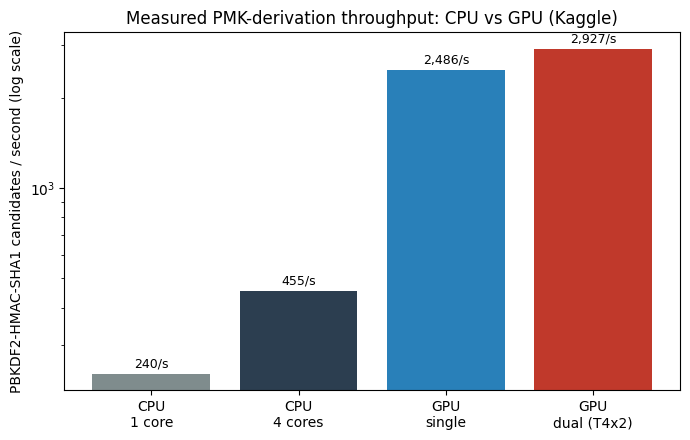

Saved: gpu_vs_cpu_throughput.png, estimate_vs_measured.csv
Download both from the Kaggle Output panel and drop them into the report's Expected Outcome / GPU appendix section.


In [8]:
import matplotlib.pyplot as plt

labels = ["CPU\n1 core", f"CPU\n{n_cores} cores", "GPU\nsingle", "GPU\ndual (T4x2)" if n_gpus >= 2 else "GPU\n(1 GPU only)"]
rates = [rate_cpu_1core, rate_cpu_ncore, rate_gpu_single, rate_gpu_dual]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, rates, color=["#7f8c8d", "#2c3e50", "#2980b9", "#c0392b"])
ax.set_yscale("log")
ax.set_ylabel("PBKDF2-HMAC-SHA1 candidates / second (log scale)")
ax.set_title("Measured PMK-derivation throughput: CPU vs GPU (Kaggle)")
for b, r in zip(bars, rates):
    ax.text(b.get_x() + b.get_width()/2, b.get_height()*1.05, f"{r:,.0f}/s", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("gpu_vs_cpu_throughput.png", dpi=150)
plt.show()

df.to_csv("estimate_vs_measured.csv", index=False)
print("Saved: gpu_vs_cpu_throughput.png, estimate_vs_measured.csv")
print("Download both from the Kaggle Output panel and drop them into the report's Expected Outcome / GPU appendix section.")


## Notes for the report

- This kernel is **our own** PyTorch implementation of PBKDF2-HMAC-SHA1, validated byte-for-byte
  against `hashlib.pbkdf2_hmac` (Step 1) -- it does not use aircrack-ng, Hashcat, or any other
  cracking tool, consistent with the assignment's "own code" rule for the graded CLI tool. This
  notebook is a **separate experimental appendix**, not a modification of `wpacrack/`.
- The GPU numbers above are for **PMK derivation only** (PBKDF2 x4096), which is ~99% of the cost
  of every attack in this project (MIC, PMKID, and mask all derive a PMK per candidate first).
  PRF-512/MIC/PMKID themselves are a handful of extra hashes and negligible by comparison.
- Report both the *worst-case* (full keyspace) and *expected* (half keyspace, on average) times
  from the table -- the report's original estimate table only had one assumed rate; this table
  shows how directly a GPU changes the "OK" vs "WEAK" verdict for short/simple passphrases.
